# MODELADO IRAIA

In [434]:
# Cargar librerias
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
np.random.seed(0)

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


import os

In [435]:
# Cargar datos
df = pd.read_csv("df_limpio_con_clusters.csv")
df_clustering= pd.read_csv("df_modelado_clustering.csv", sep=",", low_memory=False)
df_tiempo = pd.read_csv("datos_meteorologicos_2023.csv")


In [436]:
#Tamaño
print(f"Df_Limpio: {df.shape}")
print(f"Df_Tiempo: {df_tiempo.shape}")

Df_Limpio: (51707, 47)
Df_Tiempo: (3285, 22)


In [437]:
#Tipo de variables
print(df.dtypes)
print(df_tiempo.dtypes)

booked_at                          object
checkin_time                       object
lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                        

In [438]:
#Visualizar las primeras 10 filas:
print(f"Df_limpio: {df.head(10)}")
print(f"Df_tiempo: {df_tiempo.head(10)}")


Df_limpio:              booked_at         checkin_time  lead_time  lenght_of_stay  \
0  2022-11-26 16:10:00  2023-01-01 12:00:00         36               1   
1  2022-12-21 17:27:00  2023-01-01 13:09:00         11               9   
2  2022-09-21 19:46:00  2023-01-01 15:00:00        102               6   
3  2022-09-24 12:09:00  2023-01-01 15:00:00         99               1   
4  2022-10-18 07:12:00  2023-01-01 15:00:00         75               1   
5  2022-11-25 17:50:00  2023-01-01 15:00:00         37               1   
6  2022-11-26 04:10:00  2023-01-01 15:00:00         36               2   
7  2022-12-02 20:02:00  2023-01-01 15:00:00         30               1   
8  2022-12-04 23:18:00  2023-01-01 15:00:00         28               2   
9  2022-12-11 12:51:00  2023-01-01 15:00:00         21               7   

  checkin_month checkin_day  adult_count  child_count           origin  \
0       January      Sunday            1            0  channel_manager   
1       January      Sunda

Quedarnos con las variables del df que no tiene relacion con cancelaciones.

In [439]:
columnas_sin_inf_cancelaciones = [
    'checkin_time','lead_time','lenght_of_stay','checkin_month','checkin_day','adult_count','child_count',
    'origin','requested_category','asset','asset_type','business_segment','rate_type',
    'returning_inhabitant','recurrence','libere_community','reservation_net_value',
    'zona_roja_mes','Estacion_Estancia',
    'Estacion_Reserva','estancia_en_festivo','estancia_en_finde','City', 'mes_checkin_numerico',
    'reservation_checkin_month_diff', 'Reserva_Dia_Semana', 'status'
]


df_sin_inf_cancell = df[columnas_sin_inf_cancelaciones]
print(df_sin_inf_cancell)

              checkin_time  lead_time  lenght_of_stay checkin_month  \
0      2023-01-01 12:00:00         36               1       January   
1      2023-01-01 13:09:00         11               9       January   
2      2023-01-01 15:00:00        102               6       January   
3      2023-01-01 15:00:00         99               1       January   
4      2023-01-01 15:00:00         75               1       January   
...                    ...        ...             ...           ...   
51702  2023-12-31 15:00:00         79               1      December   
51703  2023-12-31 15:00:00         79               1      December   
51704  2023-12-31 15:00:00         75               1      December   
51705  2023-12-31 15:00:00         75               1      December   
51706  2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday  

Juntar ambos df-s por (Fecha, Hora, Ciudad)

In [440]:
# Cambiar nombre a la ciudad Donosti (Salen diferente)
df_sin_inf_cancell['City'] = df_sin_inf_cancell['City'].replace({'Donostia': 'Donosti'})

In [441]:
# 1. Crear FECHA desde checkin_time en df reservas
df_sin_inf_cancell['checkin_time'] = pd.to_datetime(df_sin_inf_cancell['checkin_time'])
df_sin_inf_cancell['fecha'] = df_sin_inf_cancell['checkin_time'].dt.date

# 2. Convertir FECHA en df_tiempo (es diaria)
df_tiempo['fecha'] = pd.to_datetime(df_tiempo['fecha']).dt.date


# 3. Merge SOLO por ciudad + fecha
df_junto = df_sin_inf_cancell.merge(
    df_tiempo,
    left_on=['City', 'fecha'],
    right_on=['ciudad', 'fecha'],
    how='left'
)
print(df_junto)

             checkin_time  lead_time  lenght_of_stay checkin_month  \
0     2023-01-01 12:00:00         36               1       January   
1     2023-01-01 13:09:00         11               9       January   
2     2023-01-01 15:00:00        102               6       January   
3     2023-01-01 15:00:00         99               1       January   
4     2023-01-01 15:00:00         75               1       January   
...                   ...        ...             ...           ...   
51702 2023-12-31 15:00:00         79               1      December   
51703 2023-12-31 15:00:00         79               1      December   
51704 2023-12-31 15:00:00         75               1      December   
51705 2023-12-31 15:00:00         75               1      December   
51706 2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday            1 

 Transformación Variables:
 - Eliminar variable "checkin_time" (Necesaria para el merge).
 - Tranfromar variable target "status" a tipo booleana

In [442]:
#Eliminar "checkin_time"
df_junto = df_junto.drop(columns="checkin_time")

#Tranformar Variable "status"
df_junto["status_bool"] = df_junto["status"].map(
    {"checked_out": False,
     "cancelled": True}
)
df_junto["status_bool"]

0        False
1        False
2        False
3        False
4        False
         ...  
51702    False
51703    False
51704    False
51705    False
51706     True
Name: status_bool, Length: 51707, dtype: bool

In [443]:
# Reemplazar la "," po el "." en la variables numericas sobre el tiempo:

# Primero asegurarnos de que las columnas de temperatura sean string
cols_temp = ['tmax', 'tmin', 'tmed', 'hrMedia', 'hrMax', 'hrMin', 'prec', 'dir', 'velmedia', 'racha']  

for col in cols_temp:
    # Convertir category a str
    df_junto[col] = df_junto[col].astype(str)
    # Reemplazar coma por punto
    df_junto[col] = df_junto[col].str.replace(',', '.', regex=False)
    # Convertir a float
    df_junto[col] = df_junto[col].astype(float)

# Comprobar
print(df_junto['tmax'].head(2))


0    21.4
1    21.4
Name: tmax, dtype: float64


In [444]:
#COnvertir al tipo correspodinete, sobre todo las varibales en relacion al tiempo. (Las otras ya estan)
# Bucle para convertir tipos correctamente
for col in df_junto.columns:
    # Si es object
    if df_junto[col].dtype == 'object':
        unique_vals = df_junto[col].dropna().astype(str).unique()  # asegurar que sean strings
        
        # Solo 0/1 → booleano
        if set(unique_vals).issubset({'0', '1', 0, 1}):
            df_junto[col] = df_junto[col].astype(bool)
        
        else:
            # Intentar convertir a float
            try:
                df_junto[col] = pd.to_numeric(df_junto[col], errors='raise')
            except:
                # Si no se puede → category
                df_junto[col] = df_junto[col].astype('category')
                
    # Si ya es booleano → opcional convertir a int
    elif df_junto[col].dtype == 'bool':
        df_junto[col] = df_junto[col].astype(int)


# Comprobar tipos finales
print("tmax:", df_junto["tmax"].dtypes)        # Debe salir float64
print("status_bool:", df_junto["status_bool"].dtypes)  # Debe seguir siendo int64


tmax: float64
status_bool: int64


### Seleccion Variables para los Modelos
1. Numericas: Se analizara su correlacion
2. Booleanas: 
3. Categoricas:

In [445]:
# 1. NUMERICAS:
# Seleccionar todas las columnas numéricas (int + float)

# Asegurarse de que status_bool es numérico
df_junto['status_bool'] = df_junto['status_bool'].astype(int)
# Extraer nombres de columnas numéricas
variables_numericas = df_junto.select_dtypes(include=['number']).columns.tolist()


# Verificar que 'status_bool' esté incluido
if 'status_bool' not in variables_numericas:
    variables_numericas.append('status_bool')

# Calcular correlación con status_bool
corr_df = df_junto[variables_numericas].corr()
corr_num = corr_df['status_bool'].drop('status_bool').sort_values(ascending=False)

print(corr_num.head(5))



lead_time                         0.215193
reservation_checkin_month_diff    0.210555
zona_roja_mes                     0.164497
lenght_of_stay                    0.132539
adult_count                       0.099740
Name: status_bool, dtype: float64


Variables numéricas seleccionadas (|corr| >= 0.05):
['lead_time', 'reservation_checkin_month_diff', 'zona_roja_mes', 'lenght_of_stay', 'adult_count', 'reservation_net_value', 'estancia_en_finde']
Matriz de correlación entre variables seleccionadas:
                                lead_time  reservation_checkin_month_diff  \
lead_time                        1.000000                        0.975990   
reservation_checkin_month_diff   0.975990                        1.000000   
zona_roja_mes                    0.560852                        0.596894   
lenght_of_stay                   0.097910                        0.096510   
adult_count                      0.217532                        0.215002   
reservation_net_value            0.177165                        0.175387   
estancia_en_finde                0.098692                        0.097792   

                                zona_roja_mes  lenght_of_stay  adult_count  \
lead_time                            0.560852        0.0

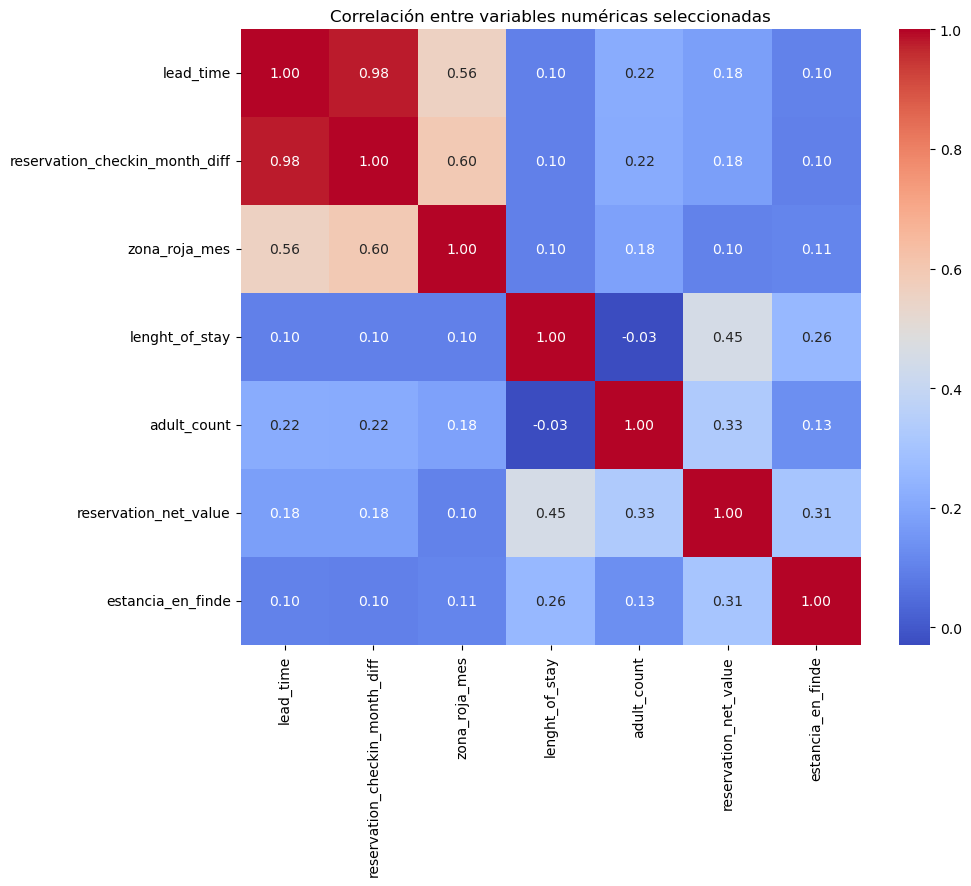

In [446]:
# Quedarnos solo con las mayores a 0.05:

# Decisión sobre el umbral: 
# Elegimos |corr| >= 0.05
# Justificación:
# - 0.05 es un umbral bajo, pero en problemas de comportamiento humano incluso señales débiles
#   pueden aportar información combinada
# - 0.10 sería más restrictivo y dejaría fuera variables con efecto pequeño pero útil

umbral = 0.05
vars_numericas_filtradas = corr_num[corr_num.abs() >= umbral].index.tolist()

print("Variables numéricas seleccionadas (|corr| >= 0.05):")
print(vars_numericas_filtradas)

# Revisar multicolinealidad entre las variables seleccionadas
# Para evitar pares altamente correlacionados (>0.7) que podrían afectar modelos lineales
# -----------------------------
corr_variables = df[vars_numericas_filtradas].corr()

print("Matriz de correlación entre variables seleccionadas:")
print(corr_variables)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_variables, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlación entre variables numéricas seleccionadas")
plt.show()

# -----------------------------
# Observaciones sobre la decisión:
# - Variables con mayor correlación con el target:
#   lead_time, reservation_checkin_month_diff, zona_roja_mes, lenght_of_stay
# - Variables con señal débil pero incluidas (|corr| ~ 0.05-0.08):
#   adult_count, reservation_net_value, estancia_en_finde
# - Ninguna variable presenta alta correlación entre sí (>0.7)
# - Decisión final: usar todas las variables seleccionadas con |corr| >= 0.05
#   para modelar cancelaciones, porque incluso señales débiles combinadas
#   pueden aportar información útil
# -----------------------------

In [447]:
# 2.  BINARIAS

# 2.1 Detectar columnas binarias (0/1 o True/False)
binarias_vars = []

for columna in df_junto.columns:
    valores_unicos = df_junto[columna].dropna().unique()
    valores_set = set(valores_unicos)
    
    if valores_set.issubset({0, 1}) or valores_set.issubset({True, False}):
        # Excluir el target
        if columna != 'status_bool':
            binarias_vars.append(columna)

print("Variables binarias detectadas:")
print(binarias_vars)

Variables binarias detectadas:
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


In [448]:
# 2.2 Revisar impacto sobre el target
target_col = 'status_bool'

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    print(f'\nColumna: {columna}')
    print(medias)


Columna: zona_roja_mes
zona_roja_mes
0    0.191143
1    0.352428
Name: status_bool, dtype: float64

Columna: estancia_en_festivo
estancia_en_festivo
0    0.229083
1    0.254162
Name: status_bool, dtype: float64

Columna: estancia_en_finde
estancia_en_finde
0    0.198288
1    0.267638
Name: status_bool, dtype: float64


In [449]:
# 2.3 Filtrar variables binarias relevantes
bin_vars_relevantes = []

umbral_diferencia = 0.02  # 2%

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    diferencia = abs(medias.iloc[1] - medias.iloc[0])
    
    if diferencia > umbral_diferencia:
        bin_vars_relevantes.append(columna)

print("\nVariables binarias relevantes (diferencia > 0.02):")
print(bin_vars_relevantes)


# -----------------------------
# Justificación:
# Consideramos relevantes aquellas variables binarias donde la diferencia 
# en la media del target entre los dos grupos supera el 2%. Diferencias pequeñas
# pueden aportar información combinada con otras variables, pero se priorizan
# aquellas con un impacto más claro sobre la cancelación.
# -----------------------------



Variables binarias relevantes (diferencia > 0.02):
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


In [450]:
# 3.  CATEGÓRICAS 

# 3.1 Detectar columnas categóricas
cat_vars = []

for columna in df_junto.columns:
    if df_junto[columna].dtype.name in ['object', 'category']:
        # Excluir la columna target
        if columna != 'status_bool':
            cat_vars.append(columna)

print("Variables categóricas detectadas:")
print(cat_vars)

Variables categóricas detectadas:
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'asset_type', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Estancia', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


In [451]:
# 3.2 Analizar impacto de variables categóricas sobre el target

target_col = 'status_bool'

for columna in cat_vars:
    # Calcular la media del target por cada categoría
    medias = df_junto.groupby(columna)[target_col].mean().sort_values(ascending=False)
    
    #print(f'\nVariable categórica: {columna}')
    #display(medias.head(10))  # Mostrar las 10 categorías con mayor media

In [452]:
# 3.3 Selección de variables categóricas relevantes

cat_vars_significativas = []

umbral_cat = 0.03  # 3%

for col in cat_vars:
    # Calcular la media del target por cada categoría
    medias_target = df_junto.groupby(col)[target_col].mean()
    
    # Diferencia máxima entre las categorías
    diferencia_max = medias_target.max() - medias_target.min()
    
    # Filtrar si supera el umbral
    if diferencia_max > umbral_cat:
        cat_vars_significativas.append(col)

print("\nVariables categóricas consideradas relevantes (diferencia > 0.03):")
print(cat_vars_significativas)

# Justificación:
# Se consideran relevantes aquellas variables categóricas donde la diferencia
# entre la categoría con mayor y menor media del target ('status_bool')
# supera el 3%. Esto refleja un impacto más claro sobre la probabilidad
# de cancelación, mientras que diferencias menores podrían aportar menos información.



Variables categóricas consideradas relevantes (diferencia > 0.03):
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


### Crear DataFrame Final para Modelado 

In [453]:
# CREAR DATAFRAME FINAL PARA MODELADO

# Unir todas las variables seleccionadas con el target
df_modelado_final = df_junto[
    vars_numericas_filtradas +       # Variables numéricas seleccionadas
    bin_vars_relevantes +            # Variables binarias relevantes
    cat_vars_significativas +        # Variables categóricas relevantes
    [target_col]                     # Target
]

# Verificar dimensiones
print(f"Dimensiones: {df_modelado_final.shape}")


Dimensiones: (51707, 35)


### Formatear el Data Frame (Numericas = Escalar, Categoricas = Dummies)

In [454]:
#Eliminar columnas de tipo fecha ya que no aportaran ningun tipo de informacion para el modelo
df_modelado_final = df_modelado_final.drop(columns=["fecha", "horatmin", "horatmax", "horaracha", "horaHrMax", "horaHrMin"])

#### Escalar Variables Numericas

In [455]:
# Función para escalar variables numéricas con MinMaxScaler
def escalar_numericas(df, columnas_numericas=None):
    """
    Escala únicamente las columnas numéricas de un DataFrame usando MinMaxScaler.
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_numericas : list (opcional)
        Lista de columnas numéricas. Si no se pasa, se detectan automáticamente.
    
    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas numéricas escaladas entre 0 y 1.
    """

    df_copy = df.copy()

    # Detectar columnas numéricas si no se pasan
    if columnas_numericas is None:
        columnas_numericas = df_copy.select_dtypes(include=['int64', 'float64']).columns.tolist()

    scaler = MinMaxScaler()

    # Escalar solo las numéricas
    df_copy[columnas_numericas] = scaler.fit_transform(df_copy[columnas_numericas])

    return df_copy

# Aplicar la función al DataFrame
df_modelado_final = escalar_numericas(df_modelado_final)

# Revisar resultado
print("Primeras filas del DataFrame con variables numéricas escaladas:")
print(df_modelado_final.head())

Primeras filas del DataFrame con variables numéricas escaladas:
   lead_time  reservation_checkin_month_diff  zona_roja_mes  lenght_of_stay  \
0   0.047461                        0.100000            0.0        0.012658   
1   0.019868                        0.066667            0.0        0.113924   
2   0.120309                        0.166667            0.0        0.075949   
3   0.116998                        0.166667            1.0        0.012658   
4   0.090508                        0.133333            1.0        0.012658   

   adult_count  reservation_net_value  estancia_en_finde  zona_roja_mes  \
0          0.1               0.015921                1.0            0.0   
1          0.1               0.117788                1.0            0.0   
2          0.2               0.755703                1.0            0.0   
3          0.2               0.186383                1.0            1.0   
4          0.4               0.077025                1.0            1.0   

   estanci

#### Convertir Categoricas a dummies

In [456]:
def convertir_a_dummies(df, columnas_categoricas=None, drop_first=True):
    """
    Convierte columnas categóricas en variables dummies (one-hot encoding).

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_categoricas : list (opcional)
        Lista de columnas categóricas. Si no se pasa, se detectan automáticamente.
    drop_first : bool
        Si True, elimina la primera categoría (evita colinealidad).

    Retorna
    -------
    pd.DataFrame
        DataFrame con las columnas categóricas convertidas en dummies.
    """

    df_copy = df.copy()

    # Detectar categóricas si no se pasan
    if columnas_categoricas is None:
        columnas_categoricas = df_copy.select_dtypes(include=['object', 'category']).columns.tolist()

    # Convertir a dummies
    df_dummies = pd.get_dummies(df_copy, columns=columnas_categoricas, drop_first=drop_first)

    return df_dummies

# Aplicar la función al DataFrame escalado
# =========================================================
df_modelado_final = convertir_a_dummies(df_modelado_final)

# Revisar resultado
print("DataFrame final con variables categóricas convertidas a dummies:")
print(df_modelado_final.head())
print(f"Dimensiones finales: {df_modelado_final.shape}")

DataFrame final con variables categóricas convertidas a dummies:
   lead_time  reservation_checkin_month_diff  zona_roja_mes  lenght_of_stay  \
0   0.047461                        0.100000            0.0        0.012658   
1   0.019868                        0.066667            0.0        0.113924   
2   0.120309                        0.166667            0.0        0.075949   
3   0.116998                        0.166667            1.0        0.012658   
4   0.090508                        0.133333            1.0        0.012658   

   adult_count  reservation_net_value  estancia_en_finde  zona_roja_mes  \
0          0.1               0.015921                1.0            0.0   
1          0.1               0.117788                1.0            0.0   
2          0.2               0.755703                1.0            0.0   
3          0.2               0.186383                1.0            1.0   
4          0.4               0.077025                1.0            1.0   

   estanc

#### Eliminar filas duplicadas:

In [457]:
# Revisar duplicados considerando todas las columnas excepto el target
duplicados = df_modelado_final.drop(columns=['status_bool']).duplicated(keep=False)
print("Filas duplicadas:", duplicados.sum())


Filas duplicadas: 5011


In [459]:
# Eliminar duplicados exactos en las features
df_modelado_final = df_modelado_final.drop_duplicates()
print("Nuevo tamaño del DataFrame:", df_modelado_final.shape)


Nuevo tamaño del DataFrame: (48759, 118)


### ----------------------------------------------------------------------------------------------------------------------------------------

### PCA 

In [460]:
# 1. Preparar los datos para PCA
# Excluir el target 'status_bool' para PCA
X = df_modelado_final.drop(columns=['status_bool'])
y = df_modelado_final['status_bool']

# 2️. Aplicar PCA
# Crear el objeto PCA, podemos empezar con todas las componentes
pca = PCA()
X_pca = pca.fit_transform(X)

In [461]:
# 3. Explicación de la varianza
# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Varianza acumulada
cumulative_variance = explained_variance.cumsum()

# Crear un DataFrame para visualizar
pca_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Varianza Explicada': explained_variance,
    'Varianza Acumulada': cumulative_variance
})

print("Varianza explicada por cada componente:")
print(pca_df.head(10))

Varianza explicada por cada componente:
  Componente  Varianza Explicada  Varianza Acumulada
0        PC1            0.138760            0.138760
1        PC2            0.093527            0.232286
2        PC3            0.080171            0.312458
3        PC4            0.057978            0.370436
4        PC5            0.054781            0.425217
5        PC6            0.046211            0.471428
6        PC7            0.042652            0.514080
7        PC8            0.038056            0.552136
8        PC9            0.028095            0.580231
9       PC10            0.025822            0.606053


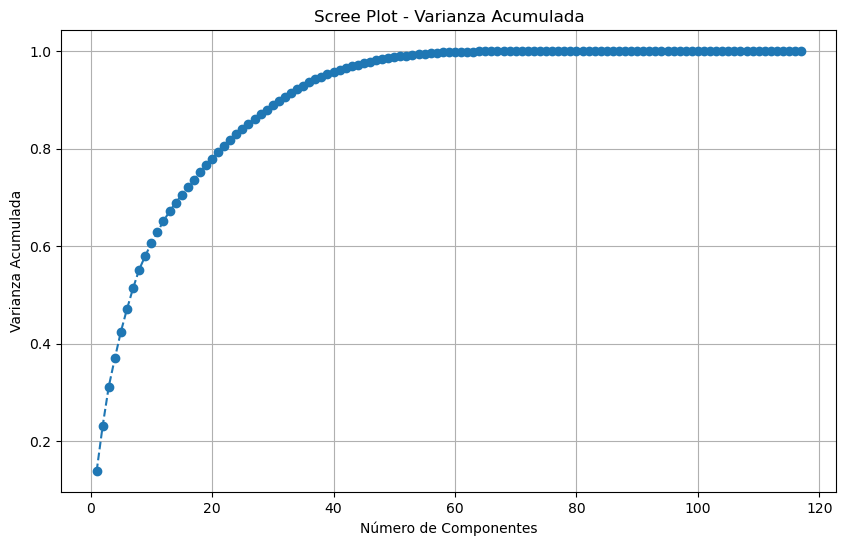

In [462]:
# 4️. Gráfico de scree plot (varianza acumulada)
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.title('Scree Plot - Varianza Acumulada')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.show()

In [463]:
# 5. Elegir el número de componentes
# Aplicar ~90% de la varianza
n_components_90 = (cumulative_variance < 0.90).sum() + 1
print(f"Número de componentes para explicar ~90% de la varianza: {n_components_90}")

Número de componentes para explicar ~90% de la varianza: 32


In [464]:
# 6. Crear DataFrame PCA final
# Podemos quedarnos solo con las primeras n componentes
pca_final = PCA(n_components=n_components_90)
X_pca_final = pca_final.fit_transform(X)

df_pca = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_pca['status_bool'] = y.values  # añadir el target para el modelado

print("Primeras filas del DataFrame PCA:")
print(df_pca.head())

Primeras filas del DataFrame PCA:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.214097 -1.052055  1.370097  0.796588  0.349127 -0.753178 -0.390721   
1  0.244586 -1.069116  1.286692  0.834759  0.333689 -0.640275 -0.196561   
2 -0.036628 -0.926119  1.519082  0.844379  0.433176 -0.579410 -0.341844   
3 -0.083233 -0.992277  1.617261  1.210528  0.667758  0.051767  0.346978   
4 -0.089008 -1.021522  1.595324  1.169076  0.673627 -0.024111  0.338228   

        PC8       PC9      PC10  ...      PC24      PC25      PC26      PC27  \
0 -0.248487  0.345844  0.634853  ...  0.349502 -0.440109  0.307777  0.794073   
1 -0.240995  0.139565  1.354408  ...  0.553715 -0.487165  0.726280 -0.240361   
2 -0.241782 -0.245781  0.040918  ...  0.256574 -0.296392 -0.148987  0.074170   
3  0.081553 -0.337688  0.027421  ...  0.091835 -0.276321  0.085846  1.080151   
4  0.087820  0.138703  0.486876  ... -0.103815 -0.256765 -0.120684  0.214116   

       PC28      PC29      PC30   

### Train / Test

In [465]:
# 1. Separar el df y target
X = df_modelado_final.drop(columns=['status_bool'])  # todas las variables excepto el target
y = df_modelado_final['status_bool']                 # target

# 2. División en train y test
# test_size = 0.2 → 20% de los datos para test
# stratify = y → asegura que la proporción de clases en train/test sea la misma que en el dataset original
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Comprobar tamaños
print(f"Tamaño X_train: {X_train.shape}")
print(f"Tamaño X_test:  {X_test.shape}")
print(f"Tamaño y_train: {y_train.shape}")
print(f"Tamaño y_test:  {y_test.shape}")

Tamaño X_train: (39007, 117)
Tamaño X_test:  (9752, 117)
Tamaño y_train: (39007,)
Tamaño y_test:  (9752,)


In [466]:
# 4️. Comprobar proporción de clases (opcional)
print("Proporción de clases en el train:")
print(y_train.value_counts(normalize=True).reset_index())
print("")
print("Proporción de clases en el test:")
print(y_test.value_counts(normalize=True).reset_index())

Proporción de clases en el train:
   status_bool  proportion
0          0.0    0.771118
1          1.0    0.228882

Proporción de clases en el test:
   status_bool  proportion
0          0.0    0.771124
1          1.0    0.228876


# MODELOS

## 1º Modelo: Regresion Logistica

In [467]:
# Regresión Logística

# 1.1 Instanciar el modelo
logreg = LogisticRegression(max_iter=1000) 
logreg

# 1.2 Entrenar el modelo
logreg_result = logreg.fit(X_train, y_train)

# 1.3 Predicciones
y_pred_classes = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:,1]  # probabilidad de clase positiva

# 1.4 Coeficientes y Odds Ratios
coefficients = logreg.coef_[0]
odds_ratios = np.exp(coefficients)

print("Número de features:", X_train.shape[1])
print("Coeficientes:", coefficients[0:5]) #Los primeros 5
print("Odds Ratios:", odds_ratios[0:5]) #Los primeros 5


Número de features: 117
Coeficientes: [0.21618977 0.24950283 0.31317993 0.13384302 0.48557413]
Odds Ratios: [1.24133793 1.2833872  1.36776761 1.14321334 1.62510776]


#### Evaluacion del Modelo

In [468]:
# 3.5 Evaluación del modelo
mean_accuracy = logreg.score(X_test, y_test)
auc = roc_auc_score(y_test, y_pred_classes)

print('Precisión media en test: {:.4f}'.format(mean_accuracy))
print('Área bajo la curva ROC (AUC): {:.4f}'.format(auc))

# 3.6 Reporte de clasificación
print("Classification Report:\n")
print(classification_report(y_test, y_pred_classes, digits=4))


Precisión media en test: 1.0000
Área bajo la curva ROC (AUC): 1.0000
Classification Report:

              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000      7520
         1.0     1.0000    1.0000    1.0000      2232

    accuracy                         1.0000      9752
   macro avg     1.0000    1.0000    1.0000      9752
weighted avg     1.0000    1.0000    1.0000      9752



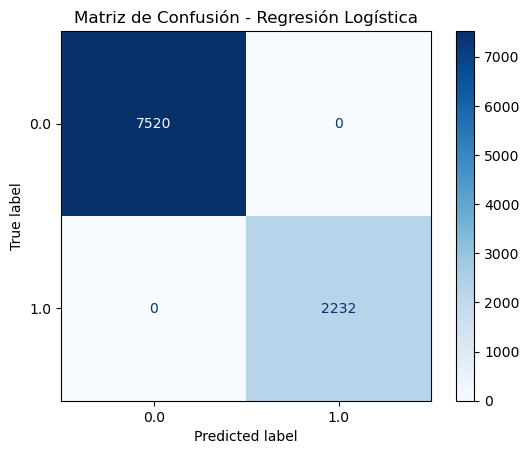

In [469]:
# 3.7 Matriz de confusión
cm = confusion_matrix(y_test, y_pred_classes, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

#### Visualizacion de probabilidades predichas

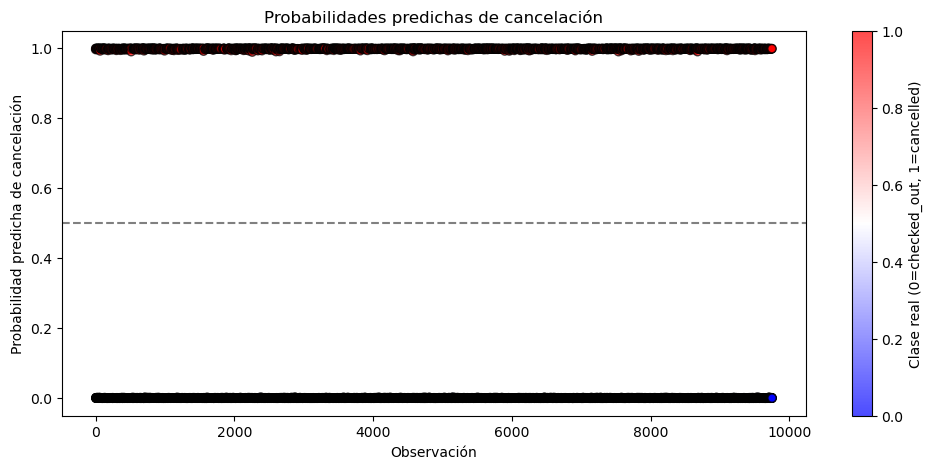

In [470]:
plt.figure(figsize=(12,5))
plt.scatter(range(len(y_test)), y_pred_proba, c=y_test, cmap='bwr', alpha=0.7, edgecolor='k')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Probabilidades predichas de cancelación")
plt.xlabel("Observación")
plt.ylabel("Probabilidad predicha de cancelación")
plt.colorbar(label='Clase real (0=checked_out, 1=cancelled)')
plt.show()

In [471]:
# 5. Interpretación de la variables: importancia de variables

# Crear un DataFrame con feature names y sus coeficientes
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': coefficients,
    'OddsRatio': odds_ratios
}).sort_values(by='OddsRatio', ascending=False)

print("Top 10 variables por efecto (Odds Ratio):")
print(coef_df.head(10))

Top 10 variables por efecto (Odds Ratio):
                                Variable  Coeficiente  OddsRatio
53   business_segment_Leisure Individual     1.167761   3.214786
115                    codigo_ccaa_ES-PV     0.664422   1.943367
58    business_segment_Travel Individual     0.554462   1.741004
34             requested_category_Studio     0.511930   1.668509
21                    checkin_day_Monday     0.490410   1.632985
4                            adult_count     0.485574   1.625108
64               Estacion_Reserva_Summer     0.463244   1.589222
5                  reservation_net_value     0.442765   1.557007
28                          origin_email     0.433129   1.542074
18                checkin_month_November     0.370310   1.448184


In [472]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report

# Separar X e y
X = df_modelado_final.drop(columns=['status_bool'])
y = df_modelado_final['status_bool']

# Logistic Regression con regularización L2
logreg = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, solver='liblinear')

# Validación cruzada 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_auc_scores = []
f1_scores = []
conf_matrices = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    y_proba = logreg.predict_proba(X_test)[:,1]
    
    roc_auc_scores.append(roc_auc_score(y_test, y_proba))
    f1_scores.append(f1_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))

print("ROC-AUC (5-fold):", np.mean(roc_auc_scores))
print("F1-score (5-fold):", np.mean(f1_scores))
print("Confusión promedio:\n", np.mean(conf_matrices, axis=0))


ROC-AUC (5-fold): 1.0
F1-score (5-fold): 1.0
Confusión promedio:
 [[7519.8    0. ]
 [   0.  2232. ]]


In [474]:
# Ejemplo
train_ids = df_modelado_final['reservation_id'].sample(frac=0.8, random_state=42)
test_ids = df_modelado_final.loc[~df_modelado_final['reservation_id'].isin(train_ids), 'reservation_id']

X_train = df_modelado_final[df_modelado_final['reservation_id'].isin(train_ids)].drop(columns=['status_bool', 'reservation_id'])
y_train = df_modelado_final[df_modelado_final['reservation_id'].isin(train_ids)]['status_bool']

X_test = df_modelado_final[df_modelado_final['reservation_id'].isin(test_ids)].drop(columns=['status_bool', 'reservation_id'])
y_test = df_modelado_final[df_modelado_final['reservation_id'].isin(test_ids)]['status_bool']


KeyError: 'reservation_id'

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score

y_pred_proba = logreg.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_pred_proba)
f1_score(y_test, y_pred)
